<a href="https://colab.research.google.com/github/prasad123253/projects/blob/main/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/data/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df[['CustomerID', 'Age']].corr()

,CustomerID,Age
CustomerID,1.000000,-0.026763
Age,-0.026763,1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

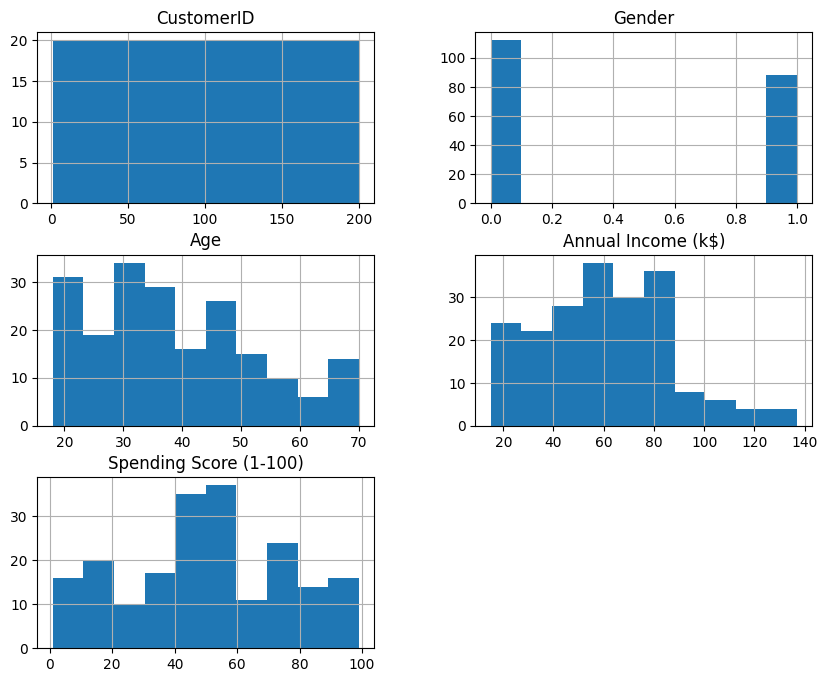

In [ ]:
df.hist(figsize=(10,8))

plt.show()

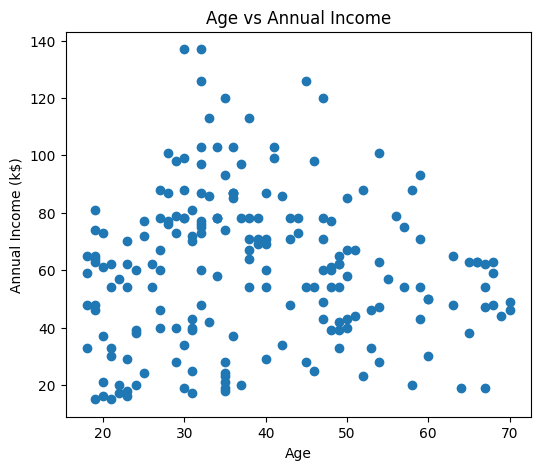

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(df["Age"], df["Annual Income (k$)"])

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Age vs Annual Income")

plt.show()

In [ ]:
X = df.drop("Spending Score (1-100)", axis=1)

y = df["Spending Score (1-100)"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
def evaluate(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
print("Logistic Regression")

evaluate(y_test, y_pred_lr)

Logistic Regression
Accuracy : 0.0
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [ ]:
print("KNN")

evaluate(y_test, y_pred_knn)

KNN
Accuracy : 0.05
Precision: 0.013333333333333332
Recall   : 0.05
F1 Score : 0.020833333333333332


In [ ]:
print("Decision Tree")

evaluate(y_test, y_pred_dt)

Decision Tree
Accuracy : 0.025
Precision: 0.025
Recall   : 0.025
F1 Score : 0.025


In [ ]:
print(df["Annual Income (k$)"].value_counts())

Annual Income (k$)
54     12
78     12
60      6
48      6
63      6
       ..
101     2
113     2
120     2
126     2
137     2
Name: count, Length: 64, dtype: int64


In [ ]:
import joblib
bestmodel=dt
joblib.dump(bestmodel,"bestmodel.pkl")
print("best model saved succesfully")

best model saved succesfully


In [ ]:
predictions = bestmodel.predict(X_test)

print(predictions)

[42 13  4 90 15 54 42 20 35 81 42 16 27 55 35 75 45 16 59 55 56 99 72 42
 55 46 42 55 71 40 99 15 60 55 16 55 40 71 16 42]
